## Business Understanding
This part of the report outlines the kinds of questions that professionals working in the real estate field may be interested in. Some questions that we are interested in exploring are:
1. How does the condition of the house affect its price (considering similar houses)?
2. Which neighbourhood consists of prime real estate?
3. How does the sale price of houses vary on a monthly basis (considering similar houses)?

## Data Understanding - Loading the Dataset
Now, we will gain more understanding about the business problem by loading the dataset and understanding the columns. The purpose of this activity is to contextualize our questions to the dataset provided by the business. We loaded the two datasets provided to us `Ames_Housing_north.csv` and `Ames_Housing_south.csv`. We started by loading the two datasets.

In [2]:
import pandas as pd

In [4]:
df_north = pd.read_csv('Ames_Housing_North.csv')
df_south = pd.read_csv('Ames_Housing_South.csv')

In [6]:
# Looking at the data
df_north.head()

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
1,527105030,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,195500
2,527127150,120,RL,41.0,4920,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,213500
3,527145080,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,0,NaN,NaN,NaN,0,1,2010,WD,Normal,191500
4,527146030,120,RL,39.0,5389,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2010,WD,Normal,236500


In [8]:
# Looking at the data
df_south.head()

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,535377090,90,RL,64.0,6979,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,600,6,2010,WD,Normal,144000
1,902102100,50,RM,60.0,4800,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2010,COD,Abnorml,80400
2,902104060,50,RM,55.0,8800,Pave,Grvl,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,96500
3,902106130,30,RM,56.0,4485,Pave,Grvl,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,5,2010,WD,Normal,109500
4,902106140,30,RM,56.0,8960,Pave,Grvl,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2010,WD,Normal,115000


In [16]:
# Looking at the features in the data
print(df_north.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2107 entries, 0 to 2106
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PID              2107 non-null   int64  
 1   MS SubClass      2107 non-null   int64  
 2   MS Zoning        2107 non-null   object 
 3   Lot Frontage     1705 non-null   float64
 4   Lot Area         2107 non-null   int64  
 5   Street           2107 non-null   object 
 6   Alley            73 non-null     object 
 7   Lot Shape        2107 non-null   object 
 8   Land Contour     2107 non-null   object 
 9   Utilities        2107 non-null   object 
 10  Lot Config       2107 non-null   object 
 11  Land Slope       2107 non-null   object 
 12  Neighborhood     2107 non-null   object 
 13  Condition 1      2107 non-null   object 
 14  Condition 2      2107 non-null   object 
 15  Bldg Type        2107 non-null   object 
 16  House Style      2107 non-null   object 
 17  Overall Qual  

In [18]:
# Looking at the features in the data
df_south.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PID              380 non-null    int64  
 1   MS SubClass      380 non-null    int64  
 2   MS Zoning        380 non-null    object 
 3   Lot Frontage     360 non-null    float64
 4   Lot Area         380 non-null    int64  
 5   Street           380 non-null    object 
 6   Alley            122 non-null    object 
 7   Lot Shape        380 non-null    object 
 8   Land Contour     380 non-null    object 
 9   Utilities        380 non-null    object 
 10  Lot Config       380 non-null    object 
 11  Land Slope       380 non-null    object 
 12  Neighborhood     380 non-null    object 
 13  Condition 1      380 non-null    object 
 14  Condition 2      380 non-null    object 
 15  Bldg Type        380 non-null    object 
 16  House Style      380 non-null    object 
 17  Overall Qual    

In [20]:
# Checking if the two dataframes have the same columns
df_north.columns.equals(df_south.columns)

True

As the two datasets have the same columns, we can concatenate them to create a single dataset.

In [22]:
# Concatenating the datasets
df = pd.concat([df_north, df_south])

In [24]:
df.columns

Index(['PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street',
       'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config',
       'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type',
       'House Style', 'Overall Qual', 'Overall Cond', 'Year Built',
       'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st',
       'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2',
       'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air',
       'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF',
       'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath',
       'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual',
       'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu',
       'Garage Type', 'Garage Yr Blt', 'Garage Finish'

Let's try to understand the columns better using the data documentation.

In [ ]:
with open('DataDocumentation.txt', 'r', encoding = 'latin1') as f:print(f.read())

Based on our examination of the data documentation, we can *PID* as our index in the dataset.

In [26]:
df.head()

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
1,527105030,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,195500
2,527127150,120,RL,41.0,4920,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,213500
3,527145080,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,0,NaN,NaN,NaN,0,1,2010,WD,Normal,191500
4,527146030,120,RL,39.0,5389,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2010,WD,Normal,236500


In [28]:
df = df.set_index('PID')

In [30]:
df.head()

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
PID,,,,,,,,,,,,,,,,,,,,,
527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
527105030,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,195500
527127150,120,RL,41.0,4920,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,213500
527145080,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,...,0,NaN,NaN,NaN,0,1,2010,WD,Normal,191500
527146030,120,RL,39.0,5389,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,3,2010,WD,Normal,236500


In [ ]:
df.shape

Based on the the dataset and the data documentation, we narrowed down our questions further as follows:
1. Which columns represent the condition of the house? How do different combinations of these relate to the *SalePrice*?
2. What makes an item of real estate prime? Which columns consist of that data? How are prime properties distributed across different values in the *Neighborhood* column?
3. Is there a seasonal pattern for buying houses throughtout the year?

## Data Understanding - Data Visualisation
In this part of the report, we will try to understand the dataset better with the help of some visualisations and descriptive statistics. We will start by creating some visualisations on relevant columns.

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

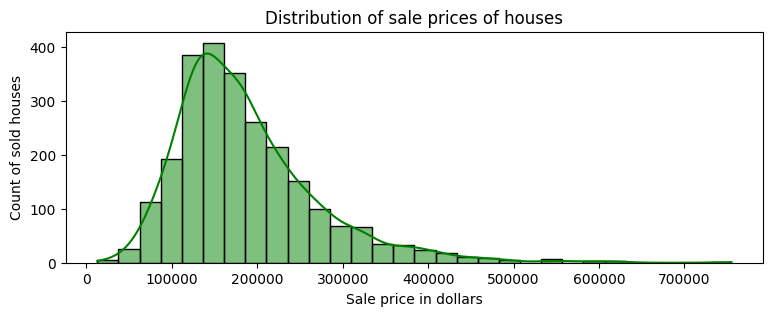

In [34]:
# Histogram of sale prices of houses
plt.figure(figsize = (9, 3))
sns.histplot(df['SalePrice'], bins = 30, kde = True, color = 'green')
plt.title('Distribution of sale prices of houses')
plt.xlabel('Sale price in dollars')
plt.ylabel('Count of sold houses')
plt.show()

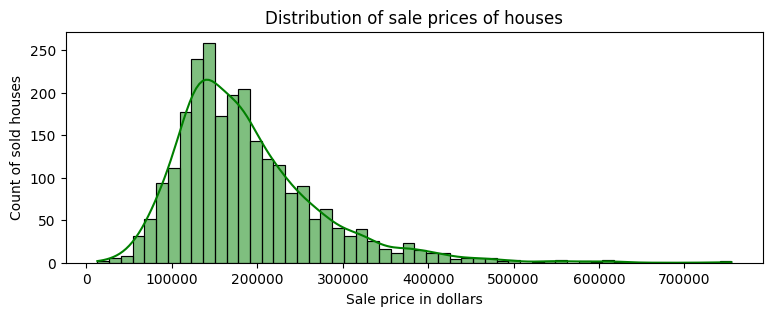

In [257]:
# Histogram of sale prices of houses
plt.figure(figsize = (9, 3))
sns.histplot(df['SalePrice'], bins = "auto", kde = True, color = 'green')
plt.title('Distribution of sale prices of houses')
plt.xlabel('Sale price in dollars')
plt.ylabel('Count of sold houses')
plt.show()

In [255]:
help(sns.histplot)

Help on function histplot in module seaborn.distributions:

histplot(data=None, *, x=None, y=None, hue=None, weights=None, stat='count', bins='auto', binwidth=None, binrange=None, discrete=None, cumulative=False, common_bins=True, common_norm=True, multiple='layer', element='bars', fill=True, shrink=1, kde=False, kde_kws=None, line_kws=None, thresh=0, pthresh=None, pmax=None, cbar=False, cbar_ax=None, cbar_kws=None, palette=None, hue_order=None, hue_norm=None, color=None, log_scale=None, legend=True, ax=None, **kwargs)
    Plot univariate or bivariate histograms to show distributions of datasets.
    
    A histogram is a classic visualization tool that represents the distribution
    of one or more variables by counting the number of observations that fall within
    discrete bins.
    
    This function can normalize the statistic computed within each bin to estimate
    frequency, density or probability mass, and it can add a smooth curve obtained
    using a kernel density estimate

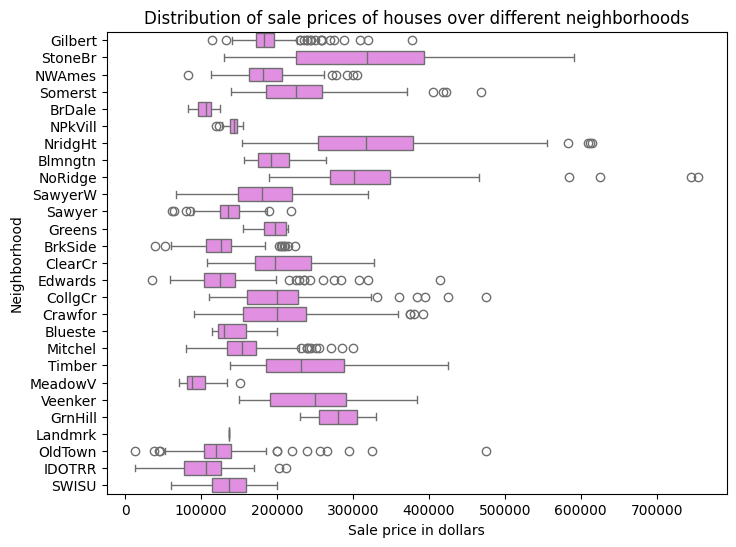

In [36]:
# Box plot of sale prices of houses by neighborhood
plt.figure(figsize = (8, 6))
sns.boxplot(data = df, x = 'SalePrice', y = 'Neighborhood', color = 'violet')
plt.title('Distribution of sale prices of houses over different neighborhoods')
plt.xlabel('Sale price in dollars')
plt.ylabel('Neighborhood')
plt.show()

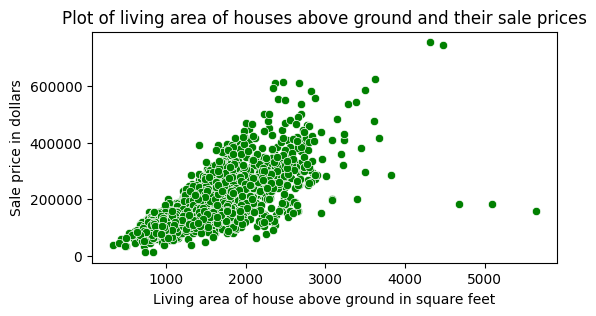

In [40]:
# Scatter plot of living area of houses above ground and their sale prices
plt.figure(figsize = (6, 3))
sns.scatterplot(x = 'Gr Liv Area', y = 'SalePrice', data = df, color = 'green')
plt.title('Plot of living area of houses above ground and their sale prices')
plt.xlabel('Living area of house above ground in square feet')
plt.ylabel('Sale price in dollars')
plt.show()

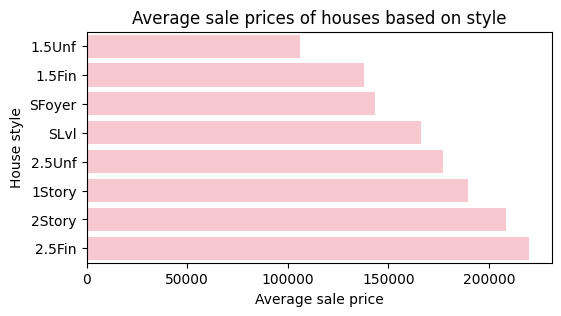

In [42]:
# Bar plot of average sale prices of houses by style of house
plt.figure(figsize = (6, 3))
avg_price_by_style = df.groupby('House Style')['SalePrice'].mean().sort_values()
sns.barplot(y = avg_price_by_style.index, x = avg_price_by_style.values, color = 'pink')
plt.title('Average sale prices of houses based on style')
plt.ylabel('House style')
plt.xlabel('Average sale price')
plt.show()

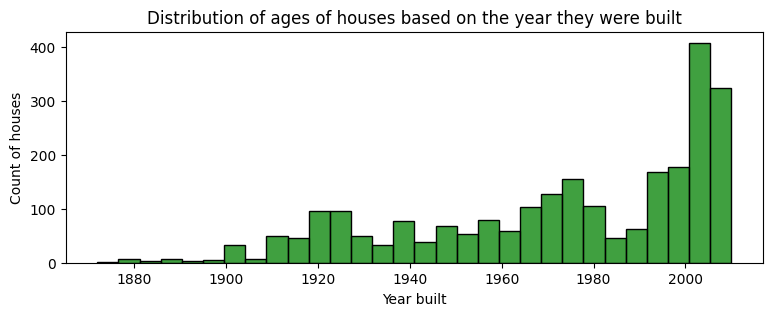

In [44]:
# Histogram of ages of houses using the year they were built
plt.figure(figsize = (9, 3))
sns.histplot(df['Year Built'], bins = 30, kde = False, color = 'green')
plt.title('Distribution of ages of houses based on the year they were built')
plt.xlabel('Year built')
plt.ylabel('Count of houses')
plt.show()

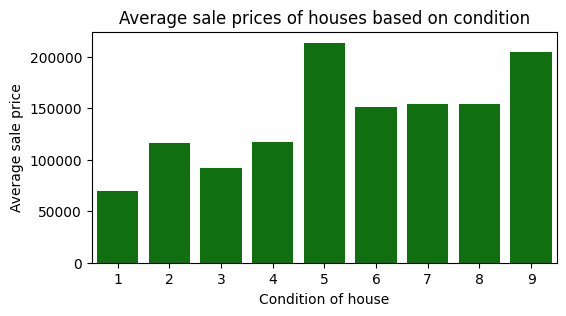

In [45]:
# Bar plot of sale prices of houses by condition
plt.figure(figsize = (6, 3))
avg_price_by_condition = df.groupby('Overall Cond')['SalePrice'].mean().sort_values()
sns.barplot(x = avg_price_by_condition.index, y = avg_price_by_condition.values, color = 'green')
plt.title('Average sale prices of houses based on condition')
plt.xlabel('Condition of house')
plt.ylabel('Average sale price')
plt.show()

## Data Understanding - Descriptive Statistics
Now we will derive relevant descriptive statistics for the data.

In [47]:
# Deriving basic descriptive statistics
basic_stats = df.describe()
print('Basic descriptive statistics:')
print(basic_stats)

Basic descriptive statistics:
       MS SubClass  Lot Frontage       Lot Area  Overall Qual  Overall Cond  \
count  2487.000000   2065.000000    2487.000000   2487.000000   2487.000000   
mean     60.800161     68.137530   10167.198633      6.230398      5.518697   
std      43.606555     23.816207    8443.945193      1.455008      1.109978   
min      20.000000     21.000000    1300.000000      1.000000      1.000000   
25%      20.000000     55.000000    7200.000000      5.000000      5.000000   
50%      60.000000     65.000000    9382.000000      6.000000      5.000000   
75%      70.000000     80.000000   11691.000000      7.000000      6.000000   
max     190.000000    313.000000  215245.000000     10.000000      9.000000   

        Year Built  Year Remod/Add  Mas Vnr Area  BsmtFin SF 1  BsmtFin SF 2  \
count  2487.000000     2487.000000   2464.000000   2486.000000   2486.000000   
mean   1973.401287     1986.691596    103.631899    435.204747     43.679405   
std      32.167949

Before we begin the analysis, we want to separate the columns into numerical and categorical columns as different descriptive statistics are relevant for different types of columns.

In [49]:
# Looking at the data types of the features in the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2487 entries, 527105010 to 911225110
Data columns (total 80 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MS SubClass      2487 non-null   int64  
 1   MS Zoning        2487 non-null   object 
 2   Lot Frontage     2065 non-null   float64
 3   Lot Area         2487 non-null   int64  
 4   Street           2487 non-null   object 
 5   Alley            195 non-null    object 
 6   Lot Shape        2487 non-null   object 
 7   Land Contour     2487 non-null   object 
 8   Utilities        2487 non-null   object 
 9   Lot Config       2487 non-null   object 
 10  Land Slope       2487 non-null   object 
 11  Neighborhood     2487 non-null   object 
 12  Condition 1      2487 non-null   object 
 13  Condition 2      2487 non-null   object 
 14  Bldg Type        2487 non-null   object 
 15  House Style      2487 non-null   object 
 16  Overall Qual     2487 non-null   int64  
 17  Overal

In [50]:
# Separating the numerical and categorical features
numerical_features = df.select_dtypes(include = ['int64', 'float64']).columns
categorical_features = df.select_dtypes(include = ['object']).columns

In [51]:
numerical_features

Index(['MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area',
       'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area',
       'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath',
       'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces',
       'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Wood Deck SF',
       'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch',
       'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold', 'SalePrice'],
      dtype='object')

In [52]:
categorical_features

Index(['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour',
       'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl',
       'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC',
       'Central Air', 'Electrical', 'Kitchen Qual', 'Functional',
       'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual',
       'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature',
       'Sale Type', 'Sale Condition'],
      dtype='object')

Let us look at the data documentation again and verify the numerical and categorical nature of these variables.

In [54]:
with open('DataDocumentation.txt', 'r', encoding = 'latin1') as f:print(f.read())

ï»¿NAME: AmesHousing.txt
TYPE: Population
SIZE: 2930 observations, 82 variables
ARTICLE TITLE: Ames Iowa: Alternative to the Boston Housing Data Set


DESCRIPTIVE ABSTRACT: Data set contains information from the Ames Assessorâs Office used in computing assessed values for individual residential properties sold in Ames, IA from 2006 to 2010.


SOURCES: 
Ames, Iowa Assessorâs Office 


VARIABLE DESCRIPTIONS:
Tab characters are used to separate variables in the data file. The data has 82 columns which include 23 nominal, 23 ordinal, 14 discrete, and 20 continuous variables (and 2 additional observation identifiers).


Order (Discrete): Observation number


PID (Nominal): Parcel identification number  - can be used with city web site for parcel review. 


MS SubClass (Nominal): Identifies the type of dwelling involved in the sale.        


       020        1-STORY 1946 & NEWER ALL STYLES
       030        1-STORY 1945 & OLDER
       040        1-STORY W/FINISHED ATTIC ALL AGES
      

Based on the data documentation, the following features have numerical values, but are actually nominal (or categorical) features:
* MS SubClass - This column is filled with codes for different types of dwellings
* Overall Qual - This is an ordinal variable, hence it can be considered as categorical
* Overall Cond - This is an ordinal variable, hence it can be considered as categorical

We will move these variables from *numerical_features* to *categorical_features*.

In [56]:
# Moving the nominal features from numerical features to categorical features
numerical_features = numerical_features.drop(['MS SubClass', 'Overall Qual', 'Overall Cond'])
categorical_features = categorical_features.append(pd.Index(['MS SubClass', 'Overall Qual', 'Overall Cond']))

Now we will calculate the mean and median for numerical variables and the mode for categorical variables.

In [58]:
# Central tendency measures for numerical features
means = df[numerical_features].mean()
medians = df[numerical_features].median()
print('Means for numerical features:')
print(means)
print('\nMedians for numerical features:')
print(medians)

Means for numerical features:
Lot Frontage           68.137530
Lot Area            10167.198633
Year Built           1973.401287
Year Remod/Add       1986.691596
Mas Vnr Area          103.631899
BsmtFin SF 1          435.204747
BsmtFin SF 2           43.679405
Bsmt Unf SF           576.354385
Total Bsmt SF        1055.238536
1st Flr SF           1156.777242
2nd Flr SF            375.018898
Low Qual Fin SF         4.879775
Gr Liv Area          1536.675915
Bsmt Full Bath          0.423742
Bsmt Half Bath          0.055131
Full Bath               1.627664
Half Bath               0.403297
Bedroom AbvGr           2.843989
Kitchen AbvGr           1.040611
TotRms AbvGrd           6.517491
Fireplaces              0.614797
Garage Yr Blt        1980.735244
Garage Cars             1.812550
Garage Area           481.653660
Wood Deck SF           99.270205
Open Porch SF          50.606755
Enclosed Porch         23.424608
3Ssn Porch              2.351830
Screen Porch           14.280257
Pool Area    

In [59]:
# Central tendency measures for categorical features
modes = df[categorical_features].mode().iloc[0]
print('Modes for categorical features:')
print(modes)

Modes for categorical features:
MS Zoning              RL
Street               Pave
Alley                Grvl
Lot Shape             Reg
Land Contour          Lvl
Utilities          AllPub
Lot Config         Inside
Land Slope            Gtl
Neighborhood      CollgCr
Condition 1          Norm
Condition 2          Norm
Bldg Type            1Fam
House Style        1Story
Roof Style          Gable
Roof Matl         CompShg
Exterior 1st      VinylSd
Exterior 2nd      VinylSd
Mas Vnr Type      BrkFace
Exter Qual             TA
Exter Cond             TA
Foundation          PConc
Bsmt Qual              Gd
Bsmt Cond              TA
Bsmt Exposure          No
BsmtFin Type 1        GLQ
BsmtFin Type 2        Unf
Heating              GasA
Heating QC             Ex
Central Air             Y
Electrical          SBrkr
Kitchen Qual           TA
Functional            Typ
Fireplace Qu           Gd
Garage Type        Attchd
Garage Finish         Unf
Garage Qual            TA
Garage Cond            TA
Paved 

We can also derive measures of position for some relevant numerical variables.

In [61]:
# Measures of position for select numerical features
select_numerical_features = ['Lot Area', 'SalePrice']
quantiles = df[select_numerical_features].quantile([0.25, 0.5, 0.75])
IQR = quantiles.loc[0.75] - quantiles.loc[0.25]
print('Quantiles (25th, 50th, 75th) for select numerical features:')
print(quantiles)
print('\nInterquartile Range (IQR) for select numerical features:')
print(IQR)

Quantiles (25th, 50th, 75th) for select numerical features:
      Lot Area  SalePrice
0.25    7200.0   130000.0
0.50    9382.0   170000.0
0.75   11691.0   224700.0

Interquartile Range (IQR) for select numerical features:
Lot Area      4491.0
SalePrice    94700.0
dtype: float64


We will now calculate measures of spread for the same variables.

In [63]:
# Measures of spread for select numerical features
variances = df[select_numerical_features].var()
print('Variance for select numerical features:')
print(variances)
std_devs = df[select_numerical_features].std()
print('\nStandard Deviation for select numerical features:')
print(std_devs)

Variance for select numerical features:
Lot Area     7.130021e+07
SalePrice    7.070845e+09
dtype: float64

Standard Deviation for select numerical features:
Lot Area      8443.945193
SalePrice    84088.315261
dtype: float64


## Data Preprocessing
In this part of our report, we will perform data pre-processing and data cleaning tasks.

In [65]:
df.head()

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
PID,,,,,,,,,,,,,,,,,,,,,
527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
527105030,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,195500
527127150,120,RL,41.0,4920,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,213500
527145080,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,...,0,NaN,NaN,NaN,0,1,2010,WD,Normal,191500
527146030,120,RL,39.0,5389,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,3,2010,WD,Normal,236500


In [66]:
df.shape

(2487, 80)

In [67]:
df.columns

Index(['MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street',
       'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config',
       'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type',
       'House Style', 'Overall Qual', 'Overall Cond', 'Year Built',
       'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st',
       'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2',
       'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air',
       'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF',
       'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath',
       'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual',
       'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu',
       'Garage Type', 'Garage Yr Blt', 'Garage Finish', 'Gara

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2487 entries, 527105010 to 911225110
Data columns (total 80 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MS SubClass      2487 non-null   int64  
 1   MS Zoning        2487 non-null   object 
 2   Lot Frontage     2065 non-null   float64
 3   Lot Area         2487 non-null   int64  
 4   Street           2487 non-null   object 
 5   Alley            195 non-null    object 
 6   Lot Shape        2487 non-null   object 
 7   Land Contour     2487 non-null   object 
 8   Utilities        2487 non-null   object 
 9   Lot Config       2487 non-null   object 
 10  Land Slope       2487 non-null   object 
 11  Neighborhood     2487 non-null   object 
 12  Condition 1      2487 non-null   object 
 13  Condition 2      2487 non-null   object 
 14  Bldg Type        2487 non-null   object 
 15  House Style      2487 non-null   object 
 16  Overall Qual     2487 non-null   int64  
 17  Overal

As the first step in data preprocessing, we will try to understand the distribution of missing values in the dataset.

In [70]:
# Checking which entries in the dataset are null values
df.isnull()

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
PID,,,,,,,,,,,,,,,,,,,,,
527105010,False,False,False,False,False,True,False,False,False,False,...,False,True,False,True,False,False,False,False,False,False
527105030,False,False,False,False,False,True,False,False,False,False,...,False,True,True,True,False,False,False,False,False,False
527127150,False,False,False,False,False,True,False,False,False,False,...,False,True,True,True,False,False,False,False,False,False
527145080,False,False,False,False,False,True,False,False,False,False,...,False,True,True,True,False,False,False,False,False,False
527146030,False,False,False,False,False,True,False,False,False,False,...,False,True,True,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
911175360,False,False,False,False,False,True,False,False,False,False,...,False,True,True,True,False,False,False,False,False,False
911175410,False,False,False,False,False,True,False,False,False,False,...,False,True,True,True,False,False,False,False,False,False
911175430,False,False,False,False,False,True,False,False,False,False,...,False,True,True,True,False,False,False,False,False,False


In [71]:
# Total number of null values in the dataset
df.isnull().sum().sum()

np.int64(13429)

In [72]:
# Percentage of null values in the dataset
100 * df.isnull().sum().sum() / (df.shape[0] * df.shape[1])

np.float64(6.749597909127463)

We will now define some helper functions to retrieve the distribution of missing values in the dataset.

In [74]:
# Helper function to return the percentages of missing values for each row
def rowpercent(df):
    row_null_vals = df.isnull().sum(axis = 1)
    row_null_vals = 100 * row_null_vals / df.shape[1]
    row_nulls = row_null_vals[row_null_vals != 0]
    row_nulls = row_nulls.sort_values(ascending = False)
    if len(row_nulls) > 0:
        print('The following shows the percentages of missing features per observation:')
        print(row_nulls)
    else:
        print('Ther are no missing values in the data set.')

# Helper function to return the percentages of missing values for each feature
def colpercent(df):
    feat_null_vals = df.isnull().sum(axis = 0)
    feat_null_vals = 100 * feat_null_vals / df.shape[0]
    feat_nulls = feat_null_vals[feat_null_vals != 0]
    feat_nulls = feat_nulls.sort_values(ascending = False)
    if len(feat_nulls) > 0:
        print('The following shows the percentages of missing observations per feature:')
        print(feat_nulls)
    else:
        print('Ther are no missing values in the data set.')

# Helper function to return the total percentage of missing values in the dataset
def nullpercent(df):
    total_nulls_percent = 100 * df.isnull().sum().sum() / (df.shape[0] * df.shape[1])
    print(f'The total amount of missing values in the data frame is about {total_nulls_percent} percent.')

In [75]:
# Checking the percentages of missing values in each row
rowpercent(df)

The following shows the percentages of missing features per observation:
PID
905228050    21.25
908201100    20.00
911175410    20.00
534450090    20.00
903232170    20.00
             ...  
534152100     2.50
532476050     2.50
527377030     2.50
902105020     2.50
527356020     1.25
Length: 2487, dtype: float64


In [76]:
# Checking the percentages of missing values in each column
colpercent(df)

The following shows the percentages of missing observations per feature:
Pool QC           99.557700
Misc Feature      96.863691
Alley             92.159228
Fence             82.790511
Mas Vnr Type      61.037394
Fireplace Qu      46.521914
Lot Frontage      16.968235
Garage Cond        5.991154
Garage Qual        5.991154
Garage Finish      5.991154
Garage Yr Blt      5.991154
Garage Type        5.910736
Bsmt Exposure      2.653800
BsmtFin Type 2     2.573382
Bsmt Cond          2.533172
Bsmt Qual          2.533172
BsmtFin Type 1     2.533172
Mas Vnr Area       0.924809
Bsmt Half Bath     0.080418
Bsmt Full Bath     0.080418
BsmtFin SF 1       0.040209
Garage Cars        0.040209
Garage Area        0.040209
Total Bsmt SF      0.040209
Bsmt Unf SF        0.040209
BsmtFin SF 2       0.040209
Electrical         0.040209
dtype: float64


In [77]:
# Checking the total percentage of missing values in the dataset
nullpercent(df)

The total amount of missing values in the data frame is about 6.749597909127463 percent.


We will begin by dealing with the missing values in the *Pool QC* feature as it has the highest percentage of missing values. Let's look at the data documentation to learn more about the *Pool QC* feature.

In [79]:
with open('DataDocumentation.txt', 'r', encoding = 'latin1') as f:print(f.read())

ï»¿NAME: AmesHousing.txt
TYPE: Population
SIZE: 2930 observations, 82 variables
ARTICLE TITLE: Ames Iowa: Alternative to the Boston Housing Data Set


DESCRIPTIVE ABSTRACT: Data set contains information from the Ames Assessorâs Office used in computing assessed values for individual residential properties sold in Ames, IA from 2006 to 2010.


SOURCES: 
Ames, Iowa Assessorâs Office 


VARIABLE DESCRIPTIONS:
Tab characters are used to separate variables in the data file. The data has 82 columns which include 23 nominal, 23 ordinal, 14 discrete, and 20 continuous variables (and 2 additional observation identifiers).


Order (Discrete): Observation number


PID (Nominal): Parcel identification number  - can be used with city web site for parcel review. 


MS SubClass (Nominal): Identifies the type of dwelling involved in the sale.        


       020        1-STORY 1946 & NEWER ALL STYLES
       030        1-STORY 1945 & OLDER
       040        1-STORY W/FINISHED ATTIC ALL AGES
      

As missing values in the *Pool QC* column may mean that there is no pool in the house, we can replace the missing values with a string `ND` as given in the data documentation. But, we can verify this assumption by checking the value of the *Pool Area* column. If the value of *Pool Area* is 0 wherever we see missing values in *Pool QC*, then our assumption is correct and we can substitute missing values with the string `ND`.

In [81]:
missing_pool_qc = df['Pool QC'].isna()
zero_pool_area = df['Pool Area'] == 0

In [82]:
coincidence = missing_pool_qc & zero_pool_area
result = df[coincidence][['Pool QC', 'Pool Area']]

In [83]:
print(result)

          Pool QC  Pool Area
PID                         
527105010     NaN          0
527105030     NaN          0
527127150     NaN          0
527145080     NaN          0
527146030     NaN          0
...           ...        ...
911175360     NaN          0
911175410     NaN          0
911175430     NaN          0
911175440     NaN          0
911225110     NaN          0

[2476 rows x 2 columns]


It seems values with 0 in *Pool Area* also have missing values in *Pool QC*. Let's verify this statement.

In [85]:
result_bool = (df[missing_pool_qc]['Pool Area'] == 0).all()

In [86]:
print(result_bool)

True


This verifies our assumption. We can safely substitute missing values in the *Pool QC* column with `ND`.

In [88]:
df['Pool QC'] = df['Pool QC'].fillna('ND')

In [89]:
colpercent(df)

The following shows the percentages of missing observations per feature:
Misc Feature      96.863691
Alley             92.159228
Fence             82.790511
Mas Vnr Type      61.037394
Fireplace Qu      46.521914
Lot Frontage      16.968235
Garage Cond        5.991154
Garage Qual        5.991154
Garage Finish      5.991154
Garage Yr Blt      5.991154
Garage Type        5.910736
Bsmt Exposure      2.653800
BsmtFin Type 2     2.573382
BsmtFin Type 1     2.533172
Bsmt Qual          2.533172
Bsmt Cond          2.533172
Mas Vnr Area       0.924809
Bsmt Half Bath     0.080418
Bsmt Full Bath     0.080418
Total Bsmt SF      0.040209
Bsmt Unf SF        0.040209
Garage Cars        0.040209
Garage Area        0.040209
BsmtFin SF 2       0.040209
BsmtFin SF 1       0.040209
Electrical         0.040209
dtype: float64


In [90]:
nullpercent(df)

The total amount of missing values in the data frame is about 5.5051266586248495 percent.


Similar to the *Pool QC* column, many other columns have associated columns which can give us more information about why there are missing values in the dataset. For example, we can compare *Mas Vnr Type* and *Mas Vnr Area*, *Fireplace Qu* with *Fireplaces*, and so on. Please continue the same process of filling `NaN`s with `ND` if you can provide a similar justification, otherwise use other methods of handling missing values.

Next, let us work on the `Mas Vnr Type` column. The column has more than 61% missing values. Similar to *Pool QC*, it also has an associated column: *Mas Vnr Area*. Let's perform a similar check here.

In [93]:
missing_mas_vnr_type = df['Mas Vnr Type'].isna()
zero_mas_vnr_area = df['Mas Vnr Area'] == 0

In [94]:
mas_vnr_result = (df[missing_mas_vnr_type]['Mas Vnr Area'] == 0).all()

In [95]:
mas_vnr_result

np.False_

Here, the statement is `False`, but we can still substitute `ND` for values where *Mas Vnr Area* is 0 and deal with the other missing values in another way.

In [97]:
mask = (df['Mas Vnr Area'] == 0) & (df['Mas Vnr Type'].isna())

In [98]:
df.loc[mask.index, 'Mas Vnr Type'] = 'ND'

In [99]:
colpercent(df)

The following shows the percentages of missing observations per feature:
Misc Feature      96.863691
Alley             92.159228
Fence             82.790511
Fireplace Qu      46.521914
Lot Frontage      16.968235
Garage Cond        5.991154
Garage Qual        5.991154
Garage Finish      5.991154
Garage Yr Blt      5.991154
Garage Type        5.910736
Bsmt Exposure      2.653800
BsmtFin Type 2     2.573382
BsmtFin Type 1     2.533172
Bsmt Qual          2.533172
Bsmt Cond          2.533172
Mas Vnr Area       0.924809
Bsmt Half Bath     0.080418
Bsmt Full Bath     0.080418
Total Bsmt SF      0.040209
Bsmt Unf SF        0.040209
Garage Cars        0.040209
Garage Area        0.040209
BsmtFin SF 2       0.040209
BsmtFin SF 1       0.040209
Electrical         0.040209
dtype: float64


For the rest of the missing values in *Mas Vnr Type*, we can impute the most common value or the mode.

In [101]:
df['Mas Vnr Type'].mode()[0]

'ND'

In [102]:
df['Mas Vnr Type'] = df['Mas Vnr Type'].fillna(df['Mas Vnr Type'].mode()[0])

In [103]:
colpercent(df)

The following shows the percentages of missing observations per feature:
Misc Feature      96.863691
Alley             92.159228
Fence             82.790511
Fireplace Qu      46.521914
Lot Frontage      16.968235
Garage Cond        5.991154
Garage Qual        5.991154
Garage Finish      5.991154
Garage Yr Blt      5.991154
Garage Type        5.910736
Bsmt Exposure      2.653800
BsmtFin Type 2     2.573382
BsmtFin Type 1     2.533172
Bsmt Qual          2.533172
Bsmt Cond          2.533172
Mas Vnr Area       0.924809
Bsmt Half Bath     0.080418
Bsmt Full Bath     0.080418
Total Bsmt SF      0.040209
Bsmt Unf SF        0.040209
Garage Cars        0.040209
Garage Area        0.040209
BsmtFin SF 2       0.040209
BsmtFin SF 1       0.040209
Electrical         0.040209
dtype: float64


Next, we will work on the missing values in the *Misc Feature*, *Alley*, *Fence* and *Fireplace Qu* features. Based on the definition of these features in the data documentation, we will replace the missing values with `ND`.

Before filling missing values in the *Misc Feature* column with `ND`, we can also check the *Misc Val* column.

In [105]:
(df[df['Misc Feature'].isna()]['Misc Val'] == 0).all()

np.True_

We can do a similar thing for *Fireplace Qu* and *Fireplaces*.

In [107]:
(df[df['Fireplace Qu'].isna()]['Fireplaces'] == 0).all()

np.True_

In [108]:
temp = ['Misc Feature', 'Alley', 'Fence', 'Fireplace Qu']
df[temp] = df[temp].fillna('ND')

In [109]:
colpercent(df)

The following shows the percentages of missing observations per feature:
Lot Frontage      16.968235
Garage Yr Blt      5.991154
Garage Qual        5.991154
Garage Finish      5.991154
Garage Cond        5.991154
Garage Type        5.910736
Bsmt Exposure      2.653800
BsmtFin Type 2     2.573382
BsmtFin Type 1     2.533172
Bsmt Cond          2.533172
Bsmt Qual          2.533172
Mas Vnr Area       0.924809
Bsmt Full Bath     0.080418
Bsmt Half Bath     0.080418
BsmtFin SF 1       0.040209
BsmtFin SF 2       0.040209
Bsmt Unf SF        0.040209
Electrical         0.040209
Garage Cars        0.040209
Garage Area        0.040209
Total Bsmt SF      0.040209
dtype: float64


In [110]:
nullpercent(df)

The total amount of missing values in the data frame is about 0.7629674306393245 percent.


Next, we will deal with the missing values in the *Lot Frontage* feature. As *Lot Frontage* is a numerical variable, we can impute the missing value with the mean of the values in this column.

In [112]:
df['Lot Frontage'].mean()

np.float64(68.13753026634383)

In [113]:
df['Lot Frontage'] = df['Lot Frontage'].fillna(df['Lot Frontage'].mean())

In [114]:
colpercent(df)

The following shows the percentages of missing observations per feature:
Garage Cond       5.991154
Garage Qual       5.991154
Garage Finish     5.991154
Garage Yr Blt     5.991154
Garage Type       5.910736
Bsmt Exposure     2.653800
BsmtFin Type 2    2.573382
Bsmt Qual         2.533172
Bsmt Cond         2.533172
BsmtFin Type 1    2.533172
Mas Vnr Area      0.924809
Bsmt Full Bath    0.080418
Bsmt Half Bath    0.080418
Total Bsmt SF     0.040209
Bsmt Unf SF       0.040209
BsmtFin SF 2      0.040209
Garage Cars       0.040209
Garage Area       0.040209
BsmtFin SF 1      0.040209
Electrical        0.040209
dtype: float64


In [115]:
nullpercent(df)

The total amount of missing values in the data frame is about 0.5508644953759549 percent.


Next, we will deal with the missing values in the categorical features related to garages, basements and masonry veneer areas. As per the data documentation, we can replace missing values in the *Garage Cond*, *Garage Qual*, *Garage Finish*, *Garage Type*, *Bsmt Exposure*, *BsmtFin Type 2*, *Bsmt Qual*, *Bsmt Cond*, *BsmtFin Type 1* and *Mas Vnr Type*  with `ND`.

In [117]:
temp = ['Garage Cond', 'Garage Qual', 'Garage Finish',
        'Garage Type', 'Bsmt Exposure', 'BsmtFin Type 2',
        'Bsmt Qual', 'Bsmt Cond', 'BsmtFin Type 1']
df[temp] = df[temp].fillna('ND')

In [118]:
colpercent(df)

The following shows the percentages of missing observations per feature:
Garage Yr Blt     5.991154
Mas Vnr Area      0.924809
Bsmt Full Bath    0.080418
Bsmt Half Bath    0.080418
BsmtFin SF 1      0.040209
BsmtFin SF 2      0.040209
Bsmt Unf SF       0.040209
Total Bsmt SF     0.040209
Electrical        0.040209
Garage Cars       0.040209
Garage Area       0.040209
dtype: float64


In [119]:
nullpercent(df)

The total amount of missing values in the data frame is about 0.09197828709288298 percent.


Next, we will deal with missing values in the numerical features related to garages, basements, and masonnry veneer areas. As per the data documentation, we can replace missing values in *Mas Vnr Area*, *Bsmt Full Bath*, *Bsmt Half Bath*, *BsmtFin SF 1*, *BsmtFin SF 2*, *Bsmt Unf SF*, *Total Bsmt SF*, *Garage Cars* and *Garage Area* with `0`.

In [121]:
temp = ['Mas Vnr Area', 'Bsmt Full Bath', 'Bsmt Half Bath',
        'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF',
        'Total Bsmt SF', 'Garage Cars', 'Garage Area']
df[temp] = df[temp].fillna(0)

In [122]:
colpercent(df)

The following shows the percentages of missing observations per feature:
Garage Yr Blt    5.991154
Electrical       0.040209
dtype: float64


In [123]:
nullpercent(df)

The total amount of missing values in the data frame is about 0.07539203860072376 percent.


Next, we will deal with missing values in the *Garage Yr Blt* feature. If the house has a garage, we can substitute values from *Year Built* into the variable *Garage Yr Blt*. We can check that using the variable *Garage Type*.

In [125]:
df[df['Garage Type'] == 'ND']['Garage Yr Blt'].isna().all()

np.True_

This is true. Therefore, we can leave the missing values in this variable.

In [127]:
colpercent(df)

The following shows the percentages of missing observations per feature:
Garage Yr Blt    5.991154
Electrical       0.040209
dtype: float64


In [128]:
nullpercent(df)

The total amount of missing values in the data frame is about 0.07539203860072376 percent.


Next, we will deal with missing values in the *Electrical* feature. As only a few values are missing from the *Electrical* column, we can drop rows instead. Let's check how many rows have missing values.

In [130]:
rowpercent(df)

The following shows the percentages of missing features per observation:
PID
534450180    1.25
904351040    1.25
909250030    1.25
535383060    1.25
902105060    1.25
             ... 
923228420    1.25
531363020    1.25
531363040    1.25
534450090    1.25
911225110    1.25
Length: 150, dtype: float64


In [131]:
df = df.drop(916386080, axis = 0)

In [132]:
nullpercent(df)

The total amount of missing values in the data frame is about 0.0749195494770716 percent.


The dataset is now clean. Let's save the cleaned dataset to the system.

In [134]:
# Saving cleaned dataset to system
df.to_csv('Ames_Housing_Cleaned.csv')

In [135]:
# Loading cleaned dataset from system
df1 = pd.read_csv('Ames_Housing_Cleaned.csv', index_col = 'PID')

In [136]:
df1.head()

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
PID,,,,,,,,,,,,,,,,,,,,,
527105010,60,RL,74.0,13830,Pave,ND,IR1,Lvl,AllPub,Inside,...,0,ND,MnPrv,ND,0,3,2010,WD,Normal,189900
527105030,60,RL,78.0,9978,Pave,ND,IR1,Lvl,AllPub,Inside,...,0,ND,ND,ND,0,6,2010,WD,Normal,195500
527127150,120,RL,41.0,4920,Pave,ND,Reg,Lvl,AllPub,Inside,...,0,ND,ND,ND,0,4,2010,WD,Normal,213500
527145080,120,RL,43.0,5005,Pave,ND,IR1,HLS,AllPub,Inside,...,0,ND,ND,ND,0,1,2010,WD,Normal,191500
527146030,120,RL,39.0,5389,Pave,ND,IR1,Lvl,AllPub,Inside,...,0,ND,ND,ND,0,3,2010,WD,Normal,236500


In [137]:
nullpercent(df1)

The total amount of missing values in the data frame is about 0.0749195494770716 percent.


In [138]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2486 entries, 527105010 to 911225110
Data columns (total 80 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MS SubClass      2486 non-null   int64  
 1   MS Zoning        2486 non-null   object 
 2   Lot Frontage     2486 non-null   float64
 3   Lot Area         2486 non-null   int64  
 4   Street           2486 non-null   object 
 5   Alley            2486 non-null   object 
 6   Lot Shape        2486 non-null   object 
 7   Land Contour     2486 non-null   object 
 8   Utilities        2486 non-null   object 
 9   Lot Config       2486 non-null   object 
 10  Land Slope       2486 non-null   object 
 11  Neighborhood     2486 non-null   object 
 12  Condition 1      2486 non-null   object 
 13  Condition 2      2486 non-null   object 
 14  Bldg Type        2486 non-null   object 
 15  House Style      2486 non-null   object 
 16  Overall Qual     2486 non-null   int64  
 17  Overal

## Exploratory Data Analysis
In this part of the report, we will perform exploratory data analysis to answer the questions that we had raised earlier. The questions are given below:
1. Which columns represent the condition of the house? How do different combinations of these relate to the *SalePrice*?
2. What makes an item of real estate prime? Which columns consist of that data? How are prime properties distributed across different values in the *Neighborhood* column?
3. Is there a seasonal pattern for buying houses throughtout the year?

### Q1
> Which columns represent the condition of the house? How do different combinations of these relate to the _SalePrice_?

Let's look at the data documentation to identify the relevant columns for this task.

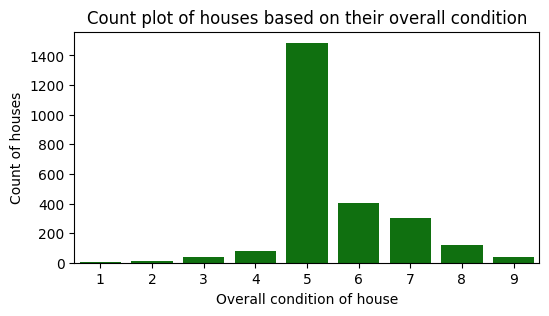

In [142]:
# Count plot of houses based on their overall condition
plt.figure(figsize = (6, 3))
sns.countplot(data = df1, x = 'Overall Cond', color = 'green')
plt.title('Count plot of houses based on their overall condition')
plt.xlabel('Overall condition of house')
plt.ylabel('Count of houses')
plt.show()

We can see that the conditions of the houses are centered around 5 with a slight skew towards higher values. Another question worth exploring is how do these condition values change for smaller/larger houses. For that we will have to subset the dataset into bins according to their areas.

In [144]:
# Computing quartiles for lot areas of houses
quartiles = df1['Lot Area'].quantile([0.25, 0.5, 0.75])

# Creating bins based on quartiles
bins = [0, quartiles[0.25], quartiles[0.5], quartiles[0.75], float('inf')]
labels = ['Q1', 'Q2', 'Q3', 'Q4']

# Binning the data
df1['Lot Area Quartile'] = pd.cut(df1['Lot Area'], bins = bins, labels = labels)

# Counting entries in each quartile
quartile_counts = df1['Lot Area Quartile'].value_counts()

print(quartile_counts)

Lot Area Quartile
Q1    643
Q4    622
Q3    621
Q2    600
Name: count, dtype: int64


We can see that the dataset is evenly distributed and the number of records in each quartile is similar.

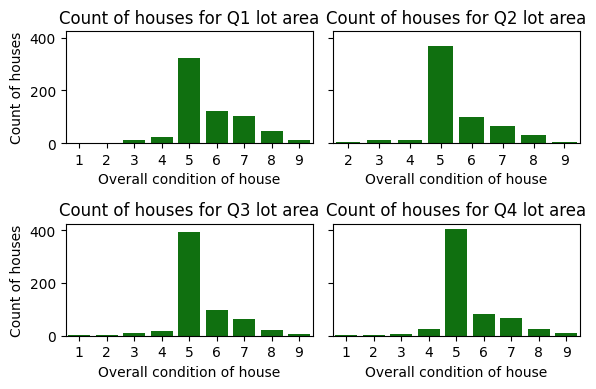

In [146]:
# Creating subplots for each quartile
fig, axes = plt.subplots(2, 2, figsize = (6, 4), sharey = True)

# Plot for each quartile
for i, quartile in enumerate(['Q1', 'Q2', 'Q3', 'Q4']):
    row = i // 2
    col = i % 2
    sns.countplot(data = df1[df1['Lot Area Quartile'] == quartile], x = 'Overall Cond',
                  ax = axes[row, col], color = 'green')
    axes[row, col].set_title(f'Count of houses for {quartile} lot area')
    axes[row, col].set_xlabel('Overall condition of house')
    axes[row, col].set_ylabel('Count of houses')

plt.tight_layout()
plt.show()

We can see that the distribution of `Overall Cond` doesn't vary too much based on the *Lot Area*. Therefore, we can move on to finding the relationship between the *Lot Area* and the *SalePrice*.

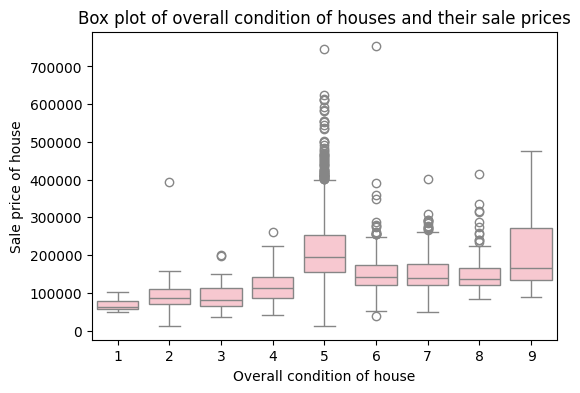

In [148]:
# Box plot of overall condition of houses and their sale prices
plt.figure(figsize = (6, 4))
sns.boxplot(data = df1, x = 'Overall Cond', y = 'SalePrice', color = 'pink')
plt.title('Box plot of overall condition of houses and their sale prices')
plt.xlabel('Overall condition of house')
plt.ylabel('Sale price of house')
plt.show()

Based on the box plot here, we can not conclude on a positive or a negative relation between the *Overall Cond* of the house and the *SalePrice*.

### Q2
> What makes an item of real estate prime? Which columns consist of that data? How are prime properties distributed across different values in the *Neighborhood* column?

To identify prime properties, we will create a new variable, namely, price per square foot of above ground living area.

In [151]:
# Engineering a price per square feet feature using the sale prices and living areas of houses
df1['PricePerSqFt'] = df1['SalePrice'] / df1['Gr Liv Area']

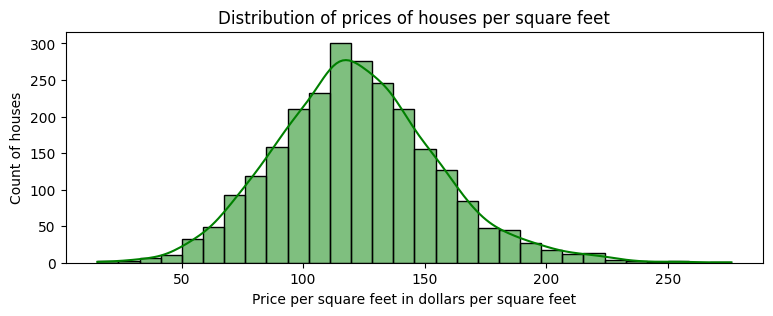

In [152]:
# Histogram of price per square feet of houses
plt.figure(figsize = (9, 3))
sns.histplot(df1['PricePerSqFt'], bins = 30, kde = True, color = 'green')
plt.title('Distribution of prices of houses per square feet')
plt.xlabel('Price per square feet in dollars per square feet')
plt.ylabel('Count of houses')
plt.show()

As you can see, the distribution of price per square foot is normal. Let's now see how this distribution varies for different neighborhoods.

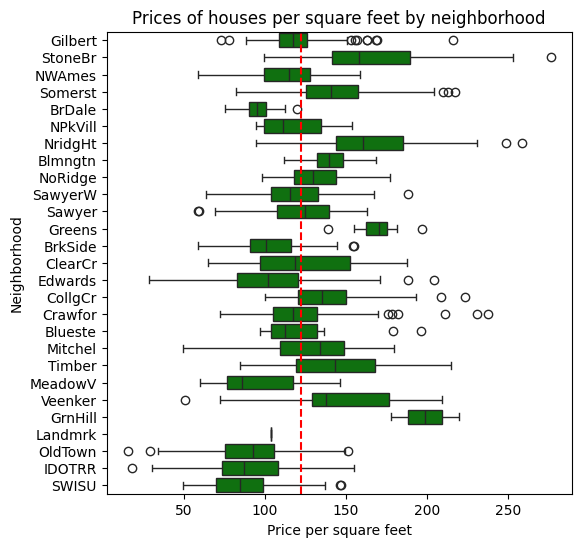

In [154]:
# Box plot of prices of houses per square feet by neighborhood
mean_price_per_sqft = df1['PricePerSqFt'].mean()
plt.figure(figsize = (6, 6))
sns.boxplot(data = df1, y = 'Neighborhood', x = 'PricePerSqFt', color = 'green')
plt.axvline(mean_price_per_sqft, color = 'r', linestyle = '--')
plt.title('Prices of houses per square feet by neighborhood')
plt.ylabel('Neighborhood')
plt.xlabel('Price per square feet')
plt.show()

This graph gives us a lot of information about the distribution of sales prices over different neighborhoods. The red line represents the mean sale price over the whole dataset and the boxplots represent the distribution of price per sqft in different neighborhoods. We can clearly see that Green Hills and Greens are prime neighborhoods whereas neighborhoods like Stone Brook and Northridge Heighs have some prime properties but the whole neighborhood has a healthy mix of property rates.

The neighborhoods exhibit significant variation in median sale prices and spread. For instance, neighborhoods like `NoRidge` and `NridgHt` have higher median prices and wider ranges, while neighborhoods like `BrDale` and `IDOTRR` show lower median prices with tighter ranges. This visualisation highlights the disparity in housing prices across different neighborhoods.

### Q3
> Is there a seasonal pattern for buying houses throughtout the year? Do some kinds of units sell more during particular periods?

In [158]:
df1['Yr Sold']

PID
527105010    2010
527105030    2010
527127150    2010
527145080    2010
527146030    2010
             ... 
911175360    2006
911175410    2006
911175430    2006
911175440    2006
911225110    2006
Name: Yr Sold, Length: 2486, dtype: int64

In [159]:
# Engineering a combined period column representing the month and year
df1['Period Sold'] = df1['Yr Sold'].astype(str) + '-' + df1['Mo Sold'].astype(str)

# Converting the period column to datetime (only year and month)
df1['Date Sold'] = pd.to_datetime(df1['Period Sold'], format = '%Y-%m')

In [160]:
# Aggregating sales data by month
monthly_sales = df1.groupby('Date Sold').size().reset_index(name = 'Monthly Sales')
print(monthly_sales)

    Date Sold  Monthly Sales
0  2006-01-01             16
1  2006-02-01             22
2  2006-03-01             39
3  2006-04-01             46
4  2006-05-01             62
5  2006-06-01             80
6  2006-07-01            104
7  2006-08-01             39
8  2006-09-01             35
9  2006-10-01             41
10 2006-11-01             27
11 2006-12-01             15
12 2007-01-01             28
13 2007-02-01             23
14 2007-03-01             46
15 2007-04-01             41
16 2007-05-01             80
17 2007-06-01             87
18 2007-07-01             86
19 2007-08-01             67
20 2007-09-01             37
21 2007-10-01             32
22 2007-11-01             34
23 2007-12-01             28
24 2008-01-01             28
25 2008-02-01             26
26 2008-03-01             32
27 2008-04-01             52
28 2008-05-01             68
29 2008-06-01             92
30 2008-07-01             89
31 2008-08-01             45
32 2008-09-01             30
33 2008-10-01 

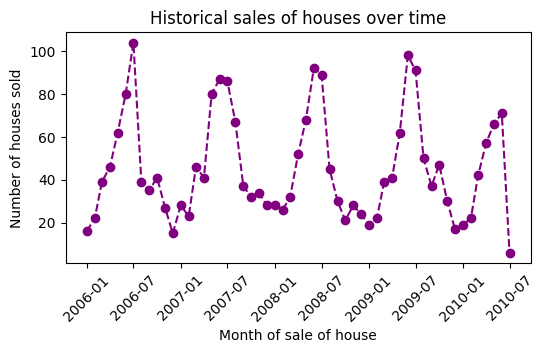

In [161]:
# Line plot of count of houses sold as a function of time
plt.figure(figsize = (6, 3))
plt.plot(monthly_sales['Date Sold'], monthly_sales['Monthly Sales'],
         marker = 'o', ls = '--', color = 'purple')
plt.title('Historical sales of houses over time')
plt.xlabel('Month of sale of house')
plt.ylabel('Number of houses sold')
plt.xticks(rotation = 45)
plt.show()

We can see that the sale of houses varies seasonally peaking in the summer months of June and July. We can now check the second part of our question, namely, whether this relationship varies for different types of houses. For this, we can bin the *SalePrice* column to divide the dataset into 4 parts by price, namely - "cheap" houses (below the 1st quartile), "average" houses (in the interquartile range), "expensive" houses (above the 3rd quartile), and "opulent" houses (over the 99th percentile in price). We can then recreate this graph for all categories to check whether this relationship holds true for different types of houses.

In [163]:
quantiles["SalePrice"]

0.25    130000.0
0.50    170000.0
0.75    224700.0
Name: SalePrice, dtype: float64

In [164]:
opulent_house_price = df['SalePrice'].quantile(0.99)
opulent_house_price

np.float64(466725.0000000001)

In [165]:
df1["SalePrice Bin"] = "opulent"
df1.loc[df1["SalePrice"] <= opulent_house_price, "SalePrice Bin"] = "expensive"
df1.loc[df1["SalePrice"] <= quantiles.loc[quantiles.index == 0.75, "SalePrice"].values[0], "SalePrice Bin"] = "average"
df1.loc[df1["SalePrice"] <= quantiles.loc[quantiles.index == 0.25, "SalePrice"].values[0], "SalePrice Bin"] = "cheap"

Now, we calculate the monthly sales for each income bin.

In [167]:
monthly_sales_binned = {}

monthly_sales_binned["Cheap"] = df1.loc[df1["SalePrice Bin"] == "cheap", :].groupby('Date Sold').size().reset_index(name = 'Monthly Sales')
monthly_sales_binned["Average"] = df1.loc[df1["SalePrice Bin"] == "average", :].groupby('Date Sold').size().reset_index(name = 'Monthly Sales')
monthly_sales_binned["Expensive"] = df1.loc[df1["SalePrice Bin"] == "expensive", :].groupby('Date Sold').size().reset_index(name = 'Monthly Sales')
monthly_sales_binned["Opulent"] = df1.loc[df1["SalePrice Bin"] == "opulent", :].groupby('Date Sold').size().reset_index(name = 'Monthly Sales')

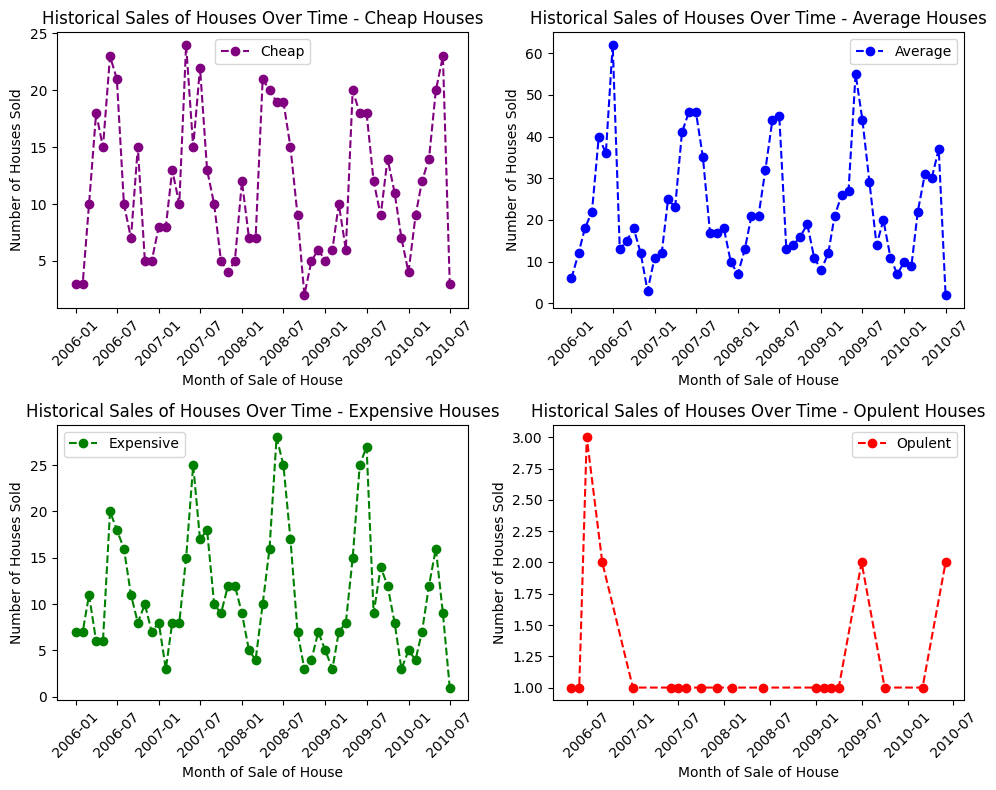

In [168]:
# Plot the line graphs for each "SalePrice Bin"
plt.figure(figsize = (10, 8))

# Define colors for each "SalePrice Bin"
colors = ['purple', 'blue', 'green', 'red']

# Loop through each bin and plot the line graph
for i, bin in enumerate(["Cheap", "Average", "Expensive", "Opulent"]):
    plt.subplot(2, 2, i+1)
    plt.plot(monthly_sales_binned[bin]['Date Sold'], monthly_sales_binned[bin]['Monthly Sales'],
             marker='o', ls = '--', color = colors[i], label = bin)
    plt.title(f'Historical Sales of Houses Over Time - {bin} Houses')
    plt.xlabel('Month of Sale of House')
    plt.ylabel('Number of Houses Sold')
    plt.xticks(rotation = 45)
    plt.legend()

plt.tight_layout()
plt.show()

We can see that the peaks for the "cheap," "average," and "expensive" houses all correspond with each other, implying that houses regardless of price were purchased at around the same times through the time period covered in our dataset. The "opulent" houses are fewer in number and no clear pattern can be found here, as the most number of houses to be sold in a month is just 3.